In [96]:
import tensorflow as tf
import PIL
import PIL.Image
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow import keras
from keras.layers import Rescaling
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [97]:
import os
import pathlib

In [98]:
dataset  = 'catdog_train_clnData/'
data_dir = pathlib.Path(dataset) 

In [99]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print (image_count)

25000


In [114]:
img_height = 200
img_width = 200
batch_size = 128

In [115]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.25,
    subset='training',
    seed=random.randint(100, 1000),
    image_size=(img_height, img_width),
    batch_size=batch_size, 
)

Found 25000 files belonging to 2 classes.
Using 18750 files for training.


In [116]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.25,
    subset='validation',
    seed=random.randint(100, 1000),
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

Found 25000 files belonging to 2 classes.
Using 6250 files for validation.


In [117]:
classnames = train_ds.class_names
print (classnames)

['cat', 'dog']


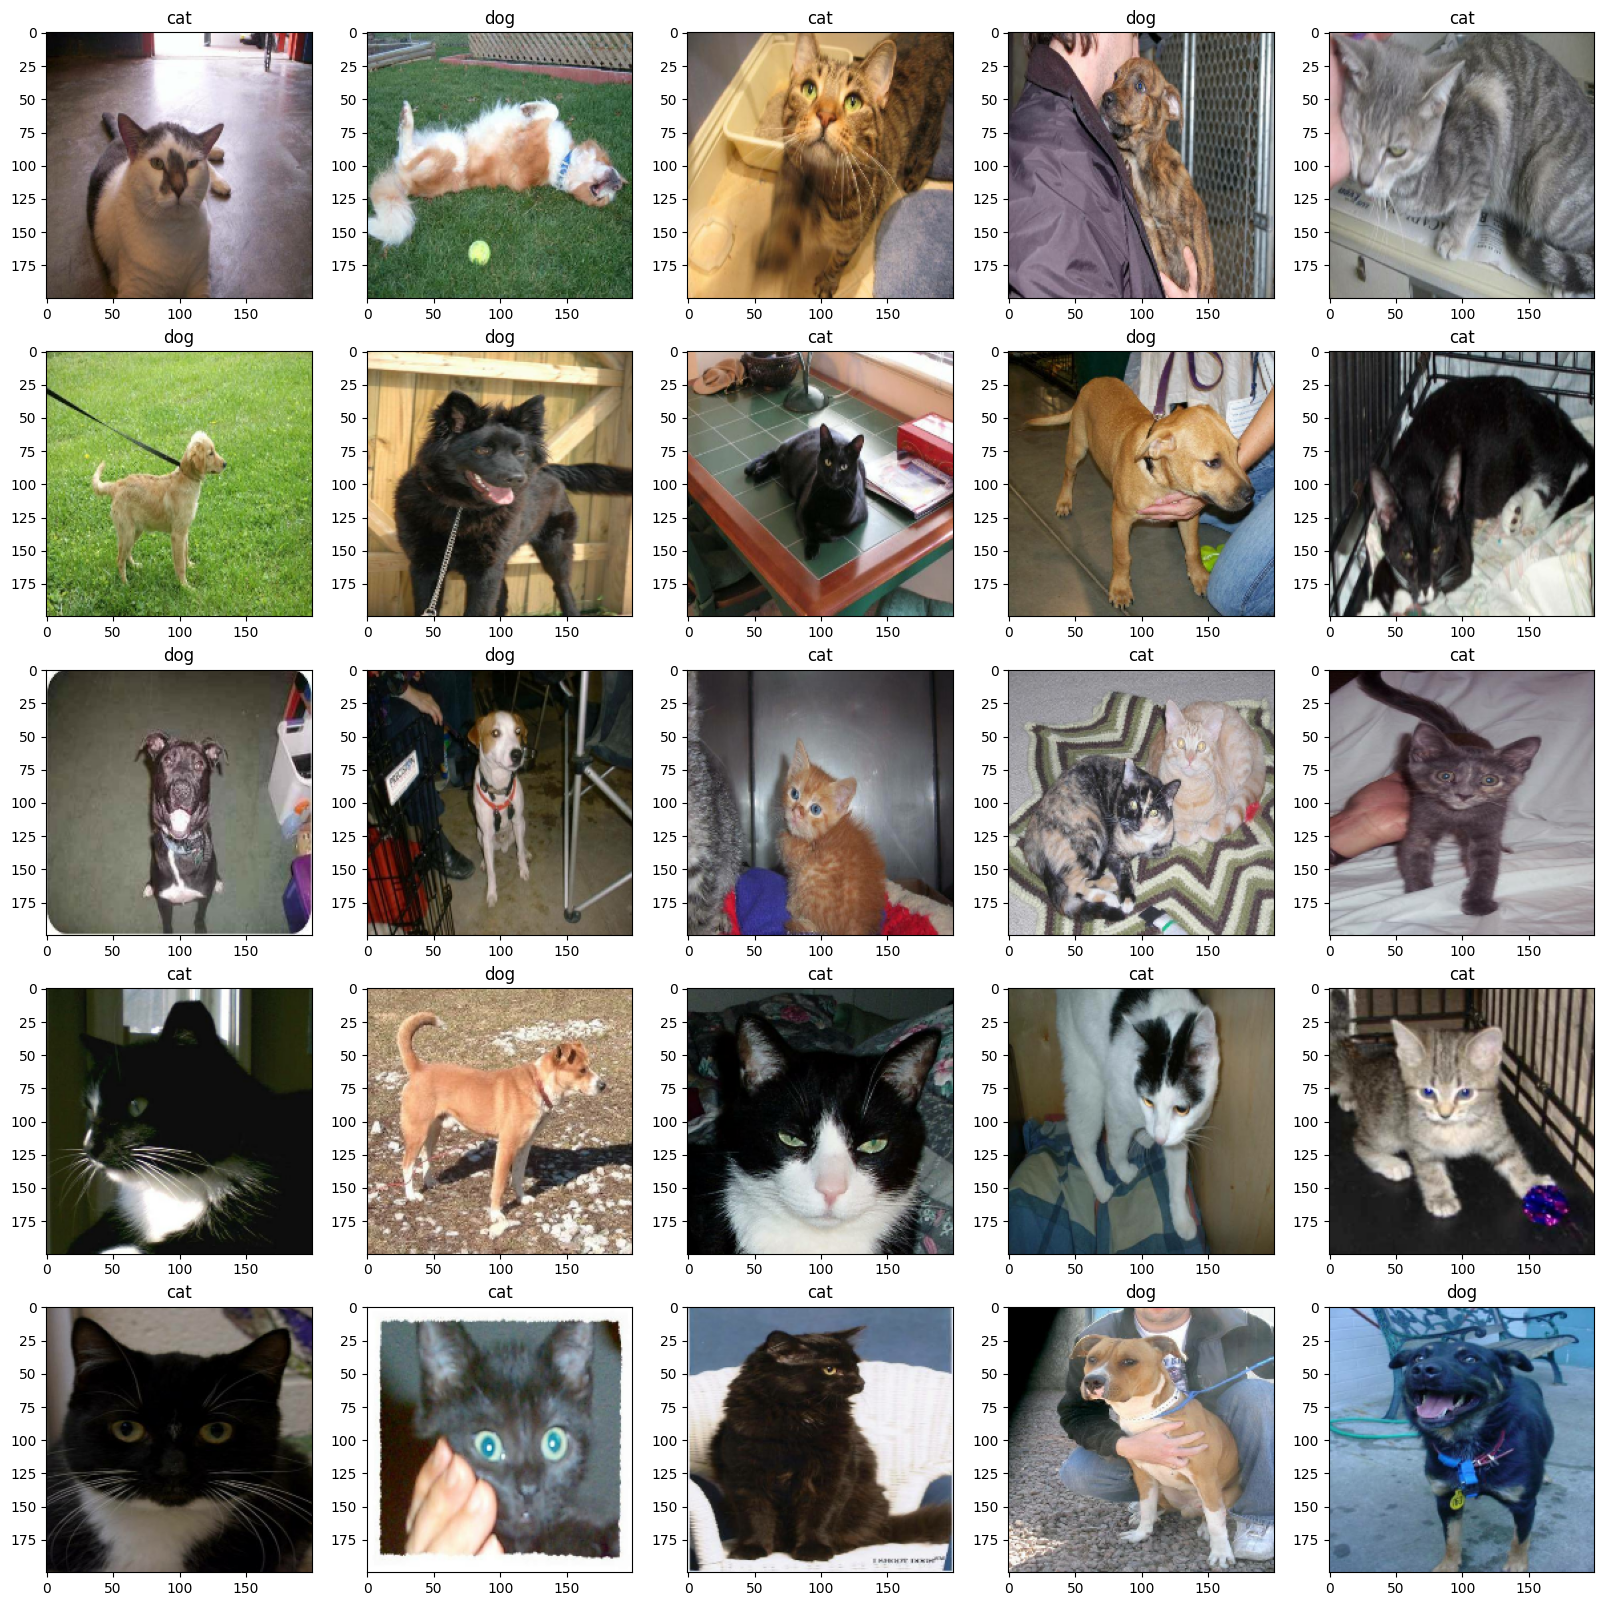

In [118]:
row, col = 5, 5

fig, axes = plt.subplots(row, col, figsize=(20, 20))        
for images, labels in train_ds.take(1):
    for i in range(row * col):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classnames[labels[i]])

In [119]:
classnames = train_ds.class_names
print (classnames)

['cat', 'dog']


In [120]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    print(labels_batch)
    break

(128, 200, 200, 3)
(128,)
tf.Tensor(
[0 0 0 1 0 0 1 1 1 1 0 0 0 1 1 0 1 1 0 1 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0
 1 0 0 1 1 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 0 0 0 0 1 0 1 0 0 1 1 1 0 1
 0 1 0 0 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 0 1 0 1 0
 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 0 1], shape=(128,), dtype=int32)


In [121]:
train_ds 

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [122]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [123]:
num_class = len(classnames)

In [124]:
model = tf.keras.Sequential([
    keras.layers.Rescaling(1./255, input_shape=(img_width, img_height, 3)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)), 
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(256, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(512, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),  
    keras.layers.Flatten(), 
    
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.5),   
    keras.layers.Dense(num_class, activation='softmax'),
])  

In [125]:
model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [126]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)              │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 198, 198, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 99, 99, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 97, 97, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 46, 46, 128)         │          36,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 21, 21, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_38 (MaxPooling2D)      │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_39 (Conv2D)                   │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_39 (MaxPooling2D)      │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,718,306 (21.81 MB)

 Trainable params: 5,718,306 (21.81 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
epochs = 20
model.fit(train_ds,
          validation_data=val_ds,
          epochs=epochs,    
)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 388s 3s/step - accuracy: 0.5288 - loss: 0.7158 - val_accuracy: 0.6469 - val_loss: 0.6303
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.6512 - loss: 0.6230 - val_accuracy: 0.6968 - val_loss: 0.5721
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - accuracy: 0.7324 - loss: 0.5409 - val_accuracy: 0.7861 - val_loss: 0.4579
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 374s 3s/step - accuracy: 0.7755 - loss: 0.4668 - val_accuracy: 0.8382 - val_loss: 0.3698
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 369s 3s/step - accuracy: 0.8349 - loss: 0.3711 - val_accuracy: 0.8677 - val_loss: 0.3128
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.8555 - loss: 0.3241 - val_accuracy: 0.8982 - val_loss: 0.2538
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.8811 - loss: 0.2821 - val_accuracy: 0.9070 - val_loss: 0.2276
Epoch 8/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 391s 3s/step - accuracy: 0.9123 - loss: 0.2161 - val_accu

## Save the model

In [128]:
model.save('9712_Model_200x200x128.keras')

## Visualize the validation data

In [ ]:
plt.figure(figsize=(15, 30))
for images, labels in val_ds.take(1):
    for i in range(36):
        ax    = plt.subplot(6, 6, i + 1)
        preds = model.predict(images)

        pred = tf.argmax(preds[i])
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f'TRUE: {classnames[labels[i]]}, PREDICT: {classnames[pred]}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step


# Load Saved Cat Dog Image Classification Model

In [130]:
model = tf.keras.models.load_model('9712_Model_200x200x128.keras')

In [134]:
def detect_catdog(model, size, img_file):
    
    image = tf.keras.utils.load_img(img_file)    
    image = image.resize(size=size)
    input_arr = tf.keras.utils.img_to_array(image)
    plt.imshow(input_arr.astype("uint8"))
    
    input_arr = np.array([input_arr])  # Convert single image to a batch. 
    predictions = model.predict(input_arr)
    top = tf.argmax(tf.nn.softmax(predictions), 1)
    
    
    
    return classnames[top[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


'cat'

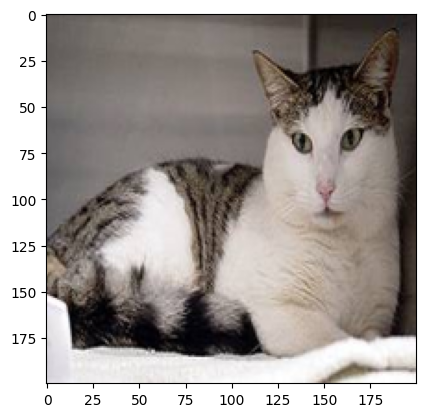

In [135]:
detect_catdog(model, (img_width, img_height), 'catdog_train_clnData/cat/cat.50.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


'dog'

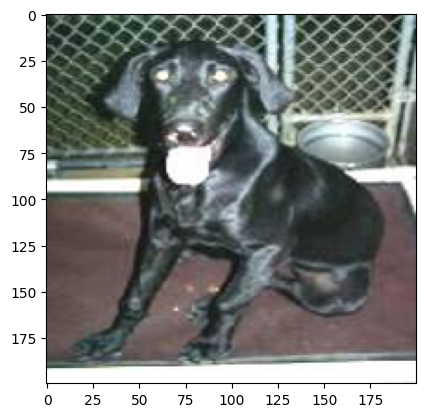

In [136]:
detect_catdog(model, (img_width, img_height), 'catdog_train_clnData/dog/dog.50.jpg')